In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Ruta del archivo CSV
ruta_archivo = r"C:\Users\marya\Desktop\Proyecto_Simulación\ProjecteData\Equip_18\Data\dataset_271025.csv"

# Cargar el archivo CSV (separado por comas)
df_BANK_marketing = pd.read_csv(ruta_archivo, sep=';')


df_BANK_marketing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         11162 non-null  int64  
 1   age        11162 non-null  float64
 2   job        11162 non-null  object 
 3   marital    11162 non-null  object 
 4   education  11162 non-null  object 
 5   default    11162 non-null  object 
 6   balance    11162 non-null  int64  
 7   housing    11162 non-null  object 
 8   loan       11162 non-null  object 
 9   contact    11162 non-null  object 
 10  day        11162 non-null  int64  
 11  month      11162 non-null  object 
 12  duration   11162 non-null  int64  
 13  campaign   11162 non-null  int64  
 14  pdays      11162 non-null  int64  
 15  previous   11162 non-null  int64  
 16  poutcome   11162 non-null  object 
 17  deposit    11162 non-null  object 
 18  age_group  11162 non-null  object 
dtypes: float64(1), int64(7), object(11)
memory usa

## 1. Porcentaje de Conversión a Depósito 

In [13]:
Suscriptores= df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes']
Num_Suscriptores = len(Suscriptores)
Total_clientes= len(df_BANK_marketing)
Porcentaje_Conversión_Depósito = round((Num_Suscriptores / Total_clientes) * 100,2)
Porcentaje_Conversión_Depósito

47.38

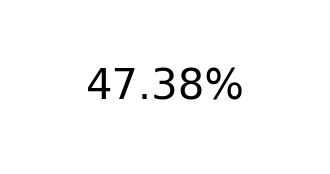

In [14]:
fig, ax = plt.subplots(figsize=(4, 2))
ax.text(0.5, 0.5, f"{Porcentaje_Conversión_Depósito:.2f}%", fontsize=30, ha='center', va='center')
ax.axis('off')
plt.show()

## 2. Promedio de Duración de Llamadas de Suscriptores 

In [28]:
Sum_Duracion_llamadas_suscriptores = df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes']['duration'].sum()
Promedio_Duracion_llamadas_suscriptores = (Sum_Duracion_llamadas_suscriptores/Num_Suscriptores).round(2)
Promedio_Duracion_llamadas_suscriptores_min= Promedio_Duracion_llamadas_suscriptores//60
s_restantes = (Promedio_Duracion_llamadas_suscriptores % 60).round(0)

print(f"Duración promedio de llamada: {int(Promedio_Duracion_llamadas_suscriptores_min)} min {int(s_restantes)} s")


Duración promedio de llamada: 8 min 57 s


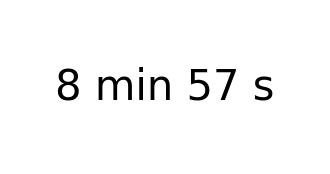

In [ ]:
minutos = int(Promedio_Duracion_llamadas_suscriptores // 60)
segundos = int((Promedio_Duracion_llamadas_suscriptores % 60).round(0))


fig, ax = plt.subplots(figsize=(4, 2))
ax.text(
    0.5, 0.5, 
    f"{minutos} min {segundos} s",  
    fontsize=30, 
    ha='center', 
    va='center'
)
ax.axis('off')
plt.show()


## 3. Porcentaje de Llamadas a Teléfono o Móvil

In [34]:

Num_Llamadas_TelefonoOMobil = len(df_BANK_marketing[df_BANK_marketing['contact'].isin(['cellular', 'telephone'])])
Num_total_llamadas = len(df_BANK_marketing)
Porcentaje_Llamadas_TelefonoOMobil  = round((Num_Llamadas_TelefonoOMobil  / Num_total_llamadas) * 100,2) 

print(Porcentaje_Llamadas_TelefonoOMobil)


78.98


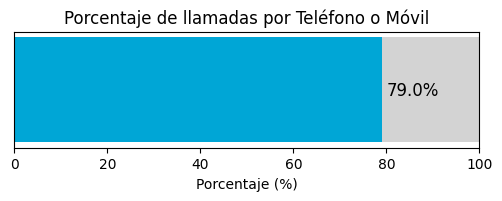

In [49]:

categorias = ['Teléfono o Móvil']
valores = [Porcentaje_Llamadas_TelefonoOMobil]  # valor en %

# Crear la "tarjeta" tipo barra de progreso
fig, ax = plt.subplots(figsize=(6, 1.5))

# Barra de fondo (100%)
ax.barh(categorias, [100], color='lightgray', height=0.5)

# Barra de valor actual
ax.barh(categorias, valores, color='#00a6d6', height=0.5)

# Etiqueta del porcentaje
for i, v in enumerate(valores):
    ax.text(v + 1, i, f"{v:.1f}%", va='center', fontsize=12)

# Ajustes estéticos
ax.set_xlim(0, 100)
ax.set_xlabel('Porcentaje (%)')
ax.set_yticks([])  # Ocultar eje y
ax.set_title('Porcentaje de llamadas por Teléfono o Móvil')
plt.show()


## 4. Promedio de Contactos Previos de Suscriptores 

In [36]:
Suscriptores= df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes']
Num_Suscriptores = len(Suscriptores)

In [37]:
Cantidad_contactos_previos_suscriptores = Suscriptores['previous'].sum()
Promedio_Contactos_Previos = (Cantidad_contactos_previos_suscriptores/Num_Suscriptores).round(2)
Promedio_Contactos_Previos

np.float64(1.17)

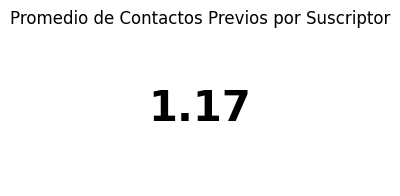

In [38]:
fig, ax = plt.subplots(figsize=(3,2))
ax.text(0.5, 0.5, f"{Promedio_Contactos_Previos}", fontsize=30, ha='center', va='center', fontweight='bold')
ax.axis('off')  # quitamos ejes
plt.title('Promedio de Contactos Previos por Suscriptor')
plt.show()

## 5. Mes con Mayor Tasa de Conversión

In [42]:
Clientes_contactados_Xmes = df_BANK_marketing.groupby('month')['deposit'].count()
Suscriptores_Xmes = df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes'].groupby('month')['deposit'].count()
Conversion_Xmes = (Suscriptores_Xmes / Clientes_contactados_Xmes * 100).round(2)
Mes_Max_Conversion = Conversion_Xmes.idxmax()
Valor_Max_Conversion = Conversion_Xmes.max()
Mes_Max_Conversion


'dec'

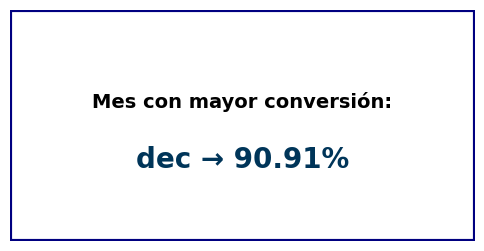

In [46]:
fig, ax = plt.subplots(figsize=(6,3))
ax.axis('off')  


rect = plt.Rectangle((0,0), 1, 1, facecolor='white', edgecolor='navy', linewidth=3)
ax.add_patch(rect)

ax.text(0.5, 0.6, f'Mes con mayor conversión:', ha='center', va='center', fontsize=14, fontweight='bold')
ax.text(0.5, 0.35, f'{Mes_Max_Conversion} → {Valor_Max_Conversion}%', ha='center', va='center', fontsize=20, color='#003559', fontweight='bold')

plt.show()

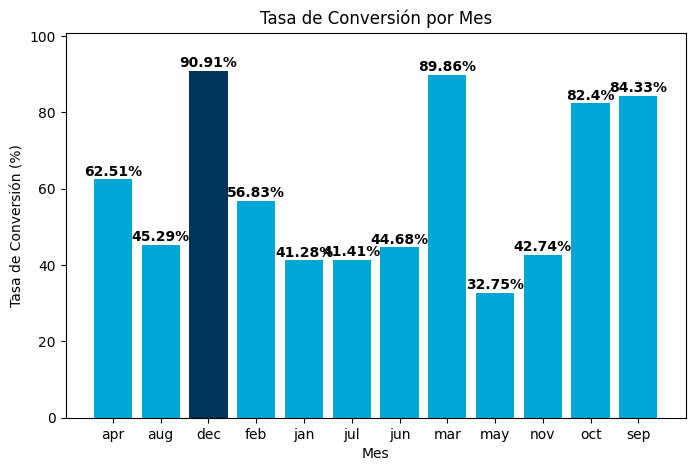

In [48]:
meses = Conversion_Xmes.index
conversion = Conversion_Xmes.values
colores = ['#00a6d6' if mes != Mes_Max_Conversion else '#003559' for mes in meses]

# Gráfico
plt.figure(figsize=(8,5))
plt.bar(meses, conversion, color=colores)
plt.ylabel('Tasa de Conversión (%)')
plt.xlabel('Mes')
plt.title('Tasa de Conversión por Mes')
plt.ylim(0, max(conversion)+10)

# Mostrar valores encima de cada barra
for i, v in enumerate(conversion):
    plt.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')

plt.show()